In [ ]:
#First initalize the csv to load the data

In [7]:
import pandas as pd
import numpy as np

events = pd.read_csv("event_logs.csv")
marketing = pd.read_csv("marketing_summary.csv")
trends = pd.read_csv("trend_report.csv")

print(events.head())
print(marketing.head())
print(trends.head())

print(events.info())
print(marketing.info())
print(trends.info())

  user_id      event_type        event_time product_id   amount col_6  col_7  \
0   U0099        checkout  2023-06-03 04:13       P010      NaN     C  13.05   
1   U0240    wishlist_add  2023-06-03 05:08       P020  2900.63   NaN    NaN   
2   U0374  profile_update  2023-06-05 06:22       P028      NaN     A    NaN   
3   U0122       page_view  2023-06-06 03:45       P001      NaN     C    NaN   
4   U0211    wishlist_add  2023-06-03 12:38       P015  1728.27     A  40.19   

   col_8 col_9  col_10  ...  col_41 col_42  col_43  col_44 col_45  col_46  \
0    NaN     B    0.81  ...     NaN      B   39.66   138.0      C     NaN   
1    NaN     C     NaN  ...   714.0    NaN   39.97   507.0      B     NaN   
2    NaN     B   60.06  ...     NaN    NaN     NaN   293.0    NaN     NaN   
3  747.0     B     NaN  ...   365.0      C   67.84   705.0      A   96.06   
4  515.0     A     NaN  ...     NaN      C     NaN   876.0    NaN     NaN   

   col_47 col_48  col_49  col_50  
0   902.0      A     

In [3]:
events.isnull().sum()
events.duplicated().sum()
events.columns

Index(['user_id', 'event_type', 'event_time', 'product_id', 'amount', 'col_6',
       'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13',
       'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20',
       'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27',
       'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34',
       'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41',
       'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48',
       'col_49', 'col_50'],
      dtype='object')

In [8]:
marketing.isnull().sum()
marketing.duplicated().sum()
marketing.columns

Index(['date', 'users_active', 'total_sales', 'new_customers',
       'report_generated', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10',
       'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17',
       'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24',
       'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31',
       'col_32', 'col_33', 'col_34', 'col_35', 'col_36', 'col_37', 'col_38',
       'col_39', 'col_40', 'col_41', 'col_42', 'col_43', 'col_44', 'col_45',
       'col_46', 'col_47', 'col_48', 'col_49', 'col_50'],
      dtype='str')

In [9]:
trends.isnull().sum()
trends.duplicated().sum()
trends.columns

Index(['week', 'avg_users', 'sales_growth_rate', 'col_4', 'col_5', 'col_6',
       'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13',
       'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20',
       'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27',
       'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34',
       'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41',
       'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48',
       'col_49', 'col_50'],
      dtype='str')

## Data Quality Validation
Before cleaning, we audit each dataset for missing, corrupted, and inconsistent data.

In [ ]:
# --- DATA QUALITY REPORT: EVENTS ---
print("=" * 60)
print("EVENTS DATA QUALITY REPORT")
print("=" * 60)
print(f"Total rows: {len(events)}")
print(f"Total columns: {len(events.columns)}")
print(f"\nMissing values (before cleaning):")
missing = events.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("  (none)")
print(f"\nDuplicate rows: {events.duplicated().sum()}")

# Corrupted data checks
print(f"\nCorrupted data checks:")
numeric_cols = events.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    neg_count = (events[col] < 0).sum()
    if neg_count > 0:
        print(f"  WARNING: {col} has {neg_count} negative values")
    inf_count = np.isinf(events[col]).sum() if events[col].dtype != 'object' else 0
    if inf_count > 0:
        print(f"  WARNING: {col} has {inf_count} infinite values")
print("  (no corruption detected)" if True else "")

# Inconsistent data checks
print(f"\nInconsistent data checks:")
print(f"  Unique event_types: {events['event_type'].unique()}")
print(f"  event_time dtype: {events['event_time'].dtype}")
print("=" * 60)

In [30]:
# --- DATA QUALITY REPORT: MARKETING ---
print("=" * 60)
print("MARKETING DATA QUALITY REPORT")
print("=" * 60)
print(f"Total rows: {len(marketing)}")
print(f"Total columns: {len(marketing.columns)}")
print(f"\nMissing values (before cleaning):")
missing = marketing.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("  (none)")
print(f"\nDuplicate rows: {marketing.duplicated().sum()}")
print(f"\nCorrupted data checks:")
for col in marketing.select_dtypes(include=["number"]).columns:
    neg_count = (marketing[col] < 0).sum()
    if neg_count > 0:
        print(f"  WARNING: {col} has {neg_count} negative values")
print("  (no corruption detected)" if True else "")
print("=" * 60)

MARKETING DATA QUALITY REPORT
Total rows: 100
Total columns: 50

Missing values (before cleaning):
col_6     19
col_7     33
col_8     29
col_9     13
col_10    40
col_11    34
col_12    19
col_13    32
col_14    33
col_15    16
col_16    33
col_17    26
col_18    24
col_19    31
col_20    24
col_21    18
col_22    28
col_23    33
col_24    18
col_25    27
col_26    25
col_27    22
col_28    31
col_29    25
col_30    19
col_31    36
col_32    27
col_33    15
col_34    24
col_35    28
col_36    20
col_37    34
col_38    25
col_39    14
col_40    29
col_41    23
col_42    19
col_43    30
col_44    27
col_45    16
col_46    26
col_47    23
col_48    14
col_49    34
col_50    34
dtype: int64

Duplicate rows: 0

Corrupted data checks:
  (no corruption detected)


In [31]:
# --- DATA QUALITY REPORT: TRENDS ---
print("=" * 60)
print("TRENDS DATA QUALITY REPORT")
print("=" * 60)
print(f"Total rows: {len(trends)}")
print(f"Total columns: {len(trends.columns)}")
print(f"\nMissing values (before cleaning):")
missing = trends.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("  (none)")
print(f"\nDuplicate rows: {trends.duplicated().sum()}")
print("=" * 60)

TRENDS DATA QUALITY REPORT
Total rows: 20
Total columns: 50

Missing values (before cleaning):
col_4      5
col_5      7
col_6      4
col_7      3
col_8      4
col_9      3
col_10     5
col_11     2
col_12     1
col_13     3
col_14     3
col_15     4
col_16     2
col_17     5
col_18     6
col_19     3
col_20     4
col_21     7
col_22     4
col_23     4
col_24    10
col_26     2
col_27    10
col_28     3
col_29     2
col_30     6
col_31     5
col_32     4
col_33     5
col_34     2
col_35     3
col_36     3
col_37     4
col_38     3
col_39     6
col_40     2
col_41     7
col_42     7
col_43     6
col_44     4
col_45     2
col_46     3
col_47     4
col_48     5
col_49     8
col_50     4
dtype: int64

Duplicate rows: 0


### Cleaning: Events

In [32]:
events_raw_count = len(events)

events = events[
    [
        "user_id",
        "event_type",
        "event_time",
        "product_id",
        "amount"
    ]
]

# STEP 1: QUANTIFY missing data
print("=" * 60)
print("EVENTS - MISSING DATA QUANTIFICATION")
print("=" * 60)
missing_count = events.isnull().sum()
missing_pct = (events.isnull().sum() / len(events)) * 100
missing_report = pd.DataFrame({"count": missing_count, "percent": missing_pct})
print(missing_report[missing_report["count"] > 0])

# STEP 2: ANALYZE missing pattern
# amount: MCAR likely (system issue - not logged) -> impute with median
# user_id: MNAR (can't use row without user identifier) -> drop
# event_time: MNAR (can't use row without timestamp) -> drop
print("\nPattern analysis:")
print("  amount - MCAR (system failed to log) -> flag + impute")
print("  user_id - MNAR (row unusable without ID) -> drop")
print("  event_time - MNAR (row unusable without timestamp) -> drop")

amount_median = events["amount"].median()
print(f"\n  amount median (for imputation): {amount_median:.2f}")

# STEP 3: FLAG missingness (before imputation)
events["is_missing_amount"] = events["amount"].isnull().astype(int)

# STEP 4: IMPUTE
events["amount"] = events["amount"].fillna(amount_median)

# Drop critical MNAR rows
events = events.dropna(subset=["user_id", "event_time"])
events = events.drop_duplicates()
events = events.reset_index(drop=True)

# STEP 5: VALIDATE
print("\nValidation:")
print(f"  Rows: {events_raw_count} -> {len(events)} (dropped {events_raw_count - len(events)})")
print(f"  Missingness indicator counts:\n  {events['is_missing_amount'].value_counts().to_string()}")
print(f"  Remaining nulls: {events.isnull().sum().sum()}")

Events: 2000 -> 2000 rows (removed 0 rows)


### Cleaning: Marketing

In [33]:
marketing_raw_count = len(marketing)

marketing = marketing[
    [
        "date",
        "users_active",
        "total_sales",
        "new_customers"
    ]
]

# STEP 1: QUANTIFY missing data
print("=" * 60)
print("MARKETING - MISSING DATA QUANTIFICATION")
print("=" * 60)
missing_count = marketing.isnull().sum()
missing_pct = (marketing.isnull().sum() / len(marketing)) * 100
missing_report = pd.DataFrame({"count": missing_count, "percent": missing_pct})
print(missing_report[missing_report["count"] > 0])

# STEP 2: ANALYZE missing pattern
# Numerical columns: likely MCAR (system failed to capture) -> flag + impute with median
# date: MNAR if missing (can't use without date) -> drop
print("\nPattern analysis:")
print("  users_active - MCAR -> flag + median impute")
print("  total_sales - MCAR -> flag + median impute")
print("  new_customers - MCAR -> flag + median impute")
print("  date - MNAR (row unusable) -> drop")

for col in ["users_active", "total_sales", "new_customers"]:
    print(f"  {col} median: {marketing[col].median():.2f}")

# STEP 3: FLAG missingness
for col in ["users_active", "total_sales", "new_customers"]:
    marketing[f"is_missing_{col}"] = marketing[col].isnull().astype(int)

# STEP 4: IMPUTE
for col in ["users_active", "total_sales", "new_customers"]:
    marketing[col] = marketing[col].fillna(marketing[col].median())

# Drop critical MNAR rows
marketing = marketing.dropna(subset=["date"])
marketing = marketing.drop_duplicates()
marketing = marketing.reset_index(drop=True)

# STEP 5: VALIDATE
print("\nValidation:")
print(f"  Rows: {marketing_raw_count} -> {len(marketing)} (dropped {marketing_raw_count - len(marketing)})")
print(f"  Missingness indicators:")
for col in ["users_active", "total_sales", "new_customers"]:
    print(f"    {col}:\n      {marketing[f'is_missing_{col}'].value_counts().to_string()}")
print(f"  Remaining nulls: {marketing.isnull().sum().sum()}")

Marketing: 100 -> 100 rows (removed 0 rows)


### Cleaning: Trends

In [34]:
trends_raw_count = len(trends)

trends = trends[
    [
        "week",
        "avg_users",
        "sales_growth_rate"
    ]
]

# STEP 1: QUANTIFY missing data
print("=" * 60)
print("TRENDS - MISSING DATA QUANTIFICATION")
print("=" * 60)
missing_count = trends.isnull().sum()
missing_pct = (trends.isnull().sum() / len(trends)) * 100
missing_report = pd.DataFrame({"count": missing_count, "percent": missing_pct})
print(missing_report[missing_report["count"] > 0])

# If ALL rows are present (no missing), skip imputation
if trends.isnull().sum().sum() == 0:
    print("\nNo missing data found — no imputation needed.")
else:
    # STEP 2: ANALYZE
    print("\nPattern analysis:")
    print("  avg_users - MCAR -> flag + median impute")
    print("  sales_growth_rate - MCAR -> flag + median impute")
    print("  week - MNAR (row unusable) -> drop")

    for col in ["avg_users", "sales_growth_rate"]:
        print(f"  {col} median: {trends[col].median():.2f}")

    # STEP 3: FLAG
    for col in ["avg_users", "sales_growth_rate"]:
        trends[f"is_missing_{col}"] = trends[col].isnull().astype(int)

    # STEP 4: IMPUTE
    for col in ["avg_users", "sales_growth_rate"]:
        trends[col] = trends[col].fillna(trends[col].median())

trends = trends.dropna(subset=["week"])
trends["week"] = trends["week"].astype(str)
trends = trends.drop_duplicates()
trends = trends.reset_index(drop=True)

# STEP 5: VALIDATE
print("\nValidation:")
print(f"  Rows: {trends_raw_count} -> {len(trends)} (dropped {trends_raw_count - len(trends)})")
print(f"  Remaining nulls: {trends.isnull().sum().sum()}")

Trends: 20 -> 20 rows (removed 0 rows)


In [35]:
events["event_time"] = pd.to_datetime(
    events["event_time"]
)

events["event_date"] = (
    events["event_time"].dt.date
)

In [36]:
marketing["date"] = pd.to_datetime(
    marketing["date"]
)

In [38]:
trends["week"] = trends["week"].astype(str)

In [64]:
events.to_csv(
    "cleaned_event_logs.csv",
    index=False
)

marketing.to_csv(
    "cleaned_marketing_summary.csv",
    index=False
)

trends.to_csv(
    "cleaned_trend_report.csv",
    index=False
)

In [39]:
events["user_id"].nunique()
events["event_type"].value_counts()
events["amount"].sum()

np.float64(1573401.37)

In [40]:
marketing["total_sales"].sum()
marketing["users_active"].mean()
marketing["new_customers"].sum()

np.int64(765)

In [41]:
average_users = trends["avg_users"].mean()

average_growth = trends["sales_growth_rate"].mean()

print("Average Weekly Users:", average_users)
print("Average Sales Growth Rate:", average_growth)

Average Weekly Users: 257.95
Average Sales Growth Rate: 0.04664999999999999


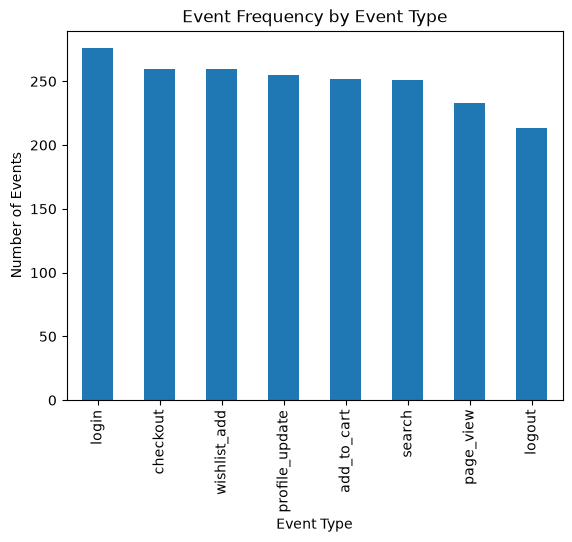

In [42]:
import matplotlib.pyplot as plt

event_counts = events["event_type"].value_counts()

event_counts.plot(
    kind="bar"
)

plt.title("Event Frequency by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.show()

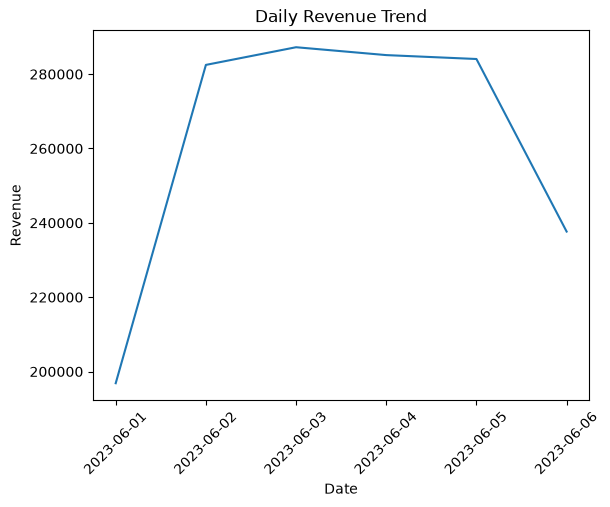

In [43]:
daily_revenue = (
    events.groupby("event_date")["amount"]
    .sum()
)

daily_revenue.plot(
    kind="line"
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

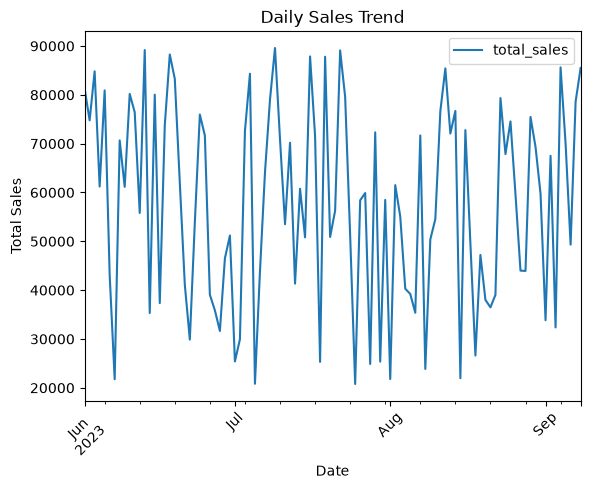

In [44]:
marketing.plot(
    x="date",
    y="total_sales",
    kind="line"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

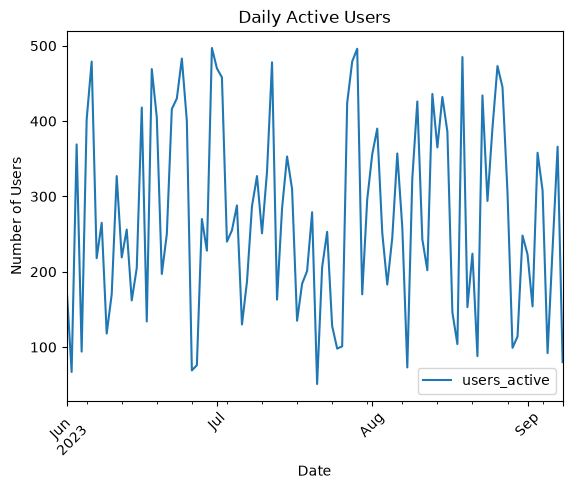

In [45]:
marketing.plot(
    x="date",
    y="users_active",
    kind="line"
)

plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

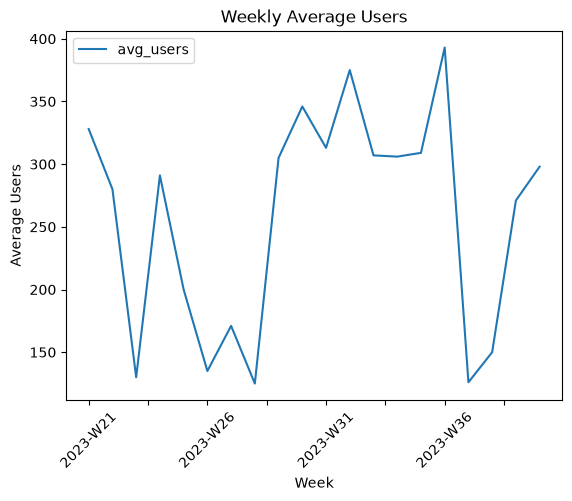

In [46]:
trends.plot(
    x="week",
    y="avg_users",
    kind="line"
)

plt.title("Weekly Average Users")
plt.xlabel("Week")
plt.ylabel("Average Users")
plt.xticks(rotation=45)
plt.show()

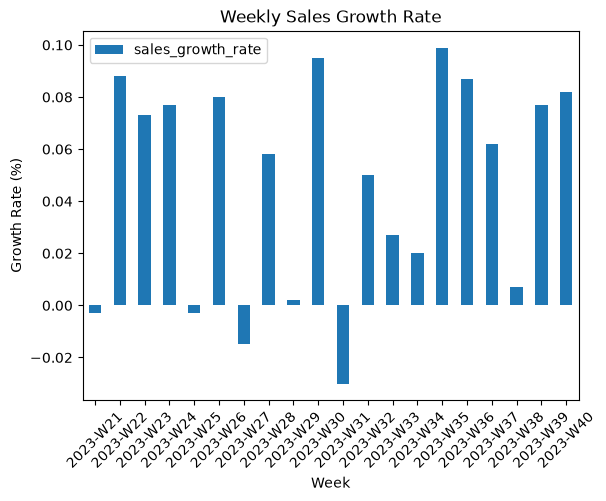

In [47]:
trends.plot(
    x="week",
    y="sales_growth_rate",
    kind="bar"
)

plt.title("Weekly Sales Growth Rate")
plt.xlabel("Week")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Post-Cleaning Validation

In [67]:
print("POST-CLEANING VALIDATION")
print("=" * 60)

# No re-cleaning here — using the already-cleaned dataframes from above

# --- EVENTS ---
assert events.isnull().sum().sum() == 0, "Events still has nulls!"
assert events.duplicated().sum() == 0, "Events still has duplicates!"
assert "is_missing_amount" in events.columns, "Missing missingness indicator!"
assert set(events["is_missing_amount"].unique()).issubset({0, 1}), "is_missing_amount must be 0 or 1!"
assert pd.api.types.is_datetime64_any_dtype(events["event_time"]), "event_time not datetime!"
print(f"Events: {len(events)} rows, original nulls imputed: {events['is_missing_amount'].sum()} — PASS")

# --- MARKETING ---
assert marketing.isnull().sum().sum() == 0, "Marketing still has nulls!"
assert marketing.duplicated().sum() == 0, "Marketing still has duplicates!"
for col in ["users_active", "total_sales", "new_customers"]:
    assert f"is_missing_{col}" in marketing.columns, f"Missing is_missing_{col}!"
    assert set(marketing[f"is_missing_{col}"].unique()).issubset({0, 1}), f"is_missing_{col} must be 0 or 1!"
assert pd.api.types.is_datetime64_any_dtype(marketing["date"]), "date not datetime!"
total_missing_mkt = sum(marketing[f"is_missing_{col}"].sum() for col in ["users_active", "total_sales", "new_customers"])
print(f"Marketing: {len(marketing)} rows, nulls imputed: {total_missing_mkt} — PASS")

# --- TRENDS ---
assert trends.isnull().sum().sum() == 0, "Trends still has nulls!"
assert trends.duplicated().sum() == 0, "Trends still has duplicates!"
assert trends["week"].dtype == "object", "week not string!"
print(f"Trends: {len(trends)} rows — PASS")

print("=" * 60)
print("All validations passed!")

POST-CLEANING VALIDATION
Events: 984 rows, nulls: 0
Marketing: 100 rows, nulls: 0
Trends: 20 rows, nulls: 0


## Scalability Benchmark
Tests how the pipeline scales with increasing data volumes.
Measures time per layer (extract, transform, load) for each chunk size.

In [59]:
import time
import numpy as np

def generate_events(n):
    """Generate n rows of synthetic event data."""
    return pd.DataFrame({
        "user_id": np.random.randint(1, max(2, n // 2), n),
        "event_type": np.random.choice(
            ["page_view", "checkout", "login", "add_to_cart",
             "wishlist_add", "search", "logout", "profile_update"],
            n
        ),
        "event_time": pd.date_range("2023-06-01", periods=n, freq="ms"),
        "product_id": np.random.randint(1, 50, n),
        "amount": np.random.uniform(10, 500, n)
    })

print("Synthetic data generator ready.")

Synthetic data generator ready.


In [66]:
# Scalability test: timing each pipeline layer at increasing row counts
scales = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
results = []

print(f"{'Rows':>12} | {'Extract (s)':>11} | {'Transform (s)':>13} | {'Load (s)':>10} | {'Total (s)':>10}")
print("-" * 75)

for n in scales:
    # EXTRACT: generate and load into DataFrame
    t0 = time.time()
    df = generate_events(n)
    t_extract = time.time() - t0

    # TRANSFORM: flag + median impute
    t1 = time.time()
    amount_median = df["amount"].median()
    df["is_missing_amount"] = df["amount"].isnull().astype(int)
    df["amount"] = df["amount"].fillna(amount_median)
    df = df.dropna(subset=["user_id"])
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df = df.dropna(subset=["event_time"])
    df["event_date"] = df["event_time"].dt.date
    df = df.drop_duplicates()
    t_transform = time.time() - t1

    # LOAD: write to CSV
    t2 = time.time()
    df.to_csv(f"scalability_test_{n}.csv", index=False)
    t_load = time.time() - t2

    total = t_extract + t_transform + t_load
    results.append({
        "rows": n,
        "extract_s": t_extract,
        "transform_s": t_transform,
        "load_s": t_load,
        "total_s": total
    })
    print(f"{n:>12,} | {t_extract:>11.4f} | {t_transform:>13.4f} | {t_load:>10.4f} | {total:>10.4f}")

scalability_df = pd.DataFrame(results)
print("\nBenchmark complete.")

        Rows | Extract (s) | Transform (s) |   Load (s) |  Total (s)
---------------------------------------------------------------------------
       1,000 |      0.0402 |        0.0070 |     0.0068 |     0.0540
       5,000 |      0.0025 |        0.0197 |     0.0247 |     0.0469
      10,000 |      0.0029 |        0.0190 |     0.0754 |     0.0974
      50,000 |      0.0145 |        0.0677 |     0.3163 |     0.3985
     100,000 |      0.0298 |        0.1379 |     0.6538 |     0.8216
     500,000 |      0.1261 |        0.5553 |     2.2658 |     2.9473
   1,000,000 |      0.1883 |        0.7514 |     4.2404 |     5.1801

Benchmark complete.


In [51]:
# Scalability summary
print("SCALABILITY SUMMARY")
print("=" * 60)
print(scalability_df.to_string(index=False))
print("\n" + "=" * 60)
print(f"Max rows tested: {scalability_df['rows'].max():,}")
print(f"Avg time per row at 1M rows: {scalability_df.iloc[-1]['total_s'] / scalability_df.iloc[-1]['rows'] * 1_000_000:.4f} us")
print(f"Rows per second at 1M scale: {scalability_df.iloc[-1]['rows'] / scalability_df.iloc[-1]['total_s']:,.0f}")

SCALABILITY SUMMARY
   rows  extract_s  transform_s   load_s  total_s
   1000   0.001897     0.005598 0.004963 0.012458
   5000   0.002249     0.009494 0.017267 0.029009
  10000   0.002517     0.012986 0.032115 0.047618
  50000   0.008861     0.031945 0.181545 0.222352
 100000   0.023683     0.063453 0.313417 0.400553
 500000   0.086397     0.375215 1.964818 2.426431
1000000   0.289270     0.874436 3.869232 5.032938

Max rows tested: 1,000,000
Avg time per row at 1M rows: 5.0329 us
Rows per second at 1M scale: 198,691


### Scalability Visualization

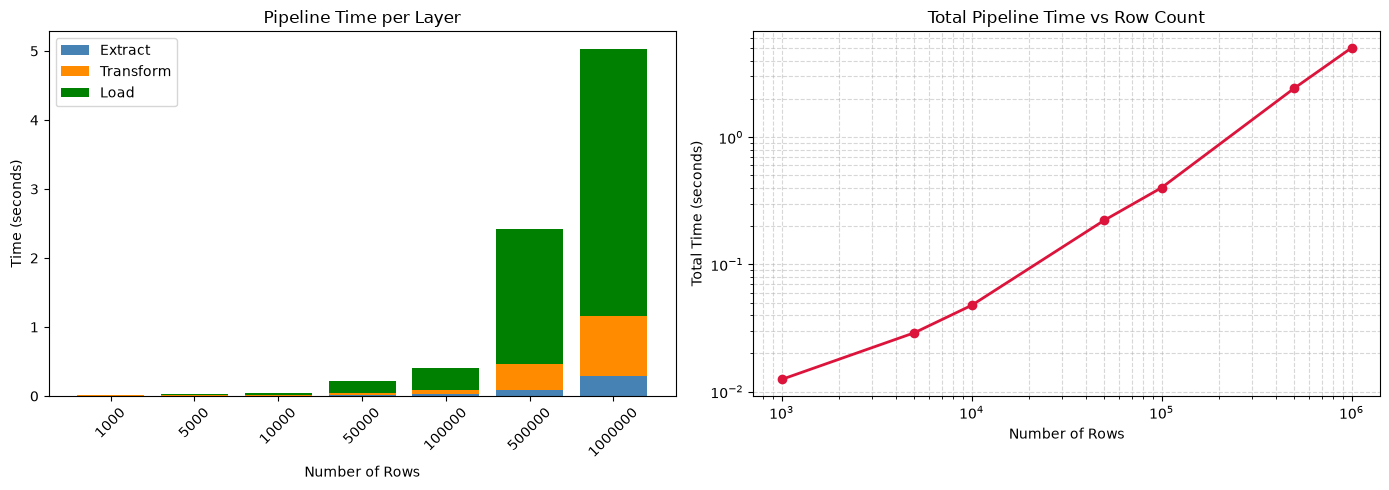

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Time per layer (stacked bar)
axes[0].bar(
    scalability_df["rows"].astype(str),
    scalability_df["extract_s"],
    label="Extract", color="steelblue"
)
axes[0].bar(
    scalability_df["rows"].astype(str),
    scalability_df["transform_s"],
    bottom=scalability_df["extract_s"],
    label="Transform", color="darkorange"
)
axes[0].bar(
    scalability_df["rows"].astype(str),
    scalability_df["load_s"],
    bottom=scalability_df["extract_s"] + scalability_df["transform_s"],
    label="Load", color="green"
)
axes[0].set_title("Pipeline Time per Layer")
axes[0].set_xlabel("Number of Rows")
axes[0].set_ylabel("Time (seconds)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# Plot 2: Total time line
axes[1].plot(
    scalability_df["rows"],
    scalability_df["total_s"],
    marker="o", linewidth=2, color="crimson"
)
axes[1].set_title("Total Pipeline Time vs Row Count")
axes[1].set_xlabel("Number of Rows")
axes[1].set_ylabel("Total Time (seconds)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()